Prueba

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.2/934.2 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.5/869.5 kB 44.0 MB/s eta 0:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts.models import TFTModel
from darts import TimeSeries
import torch
import pytorch_lightning as pl
#from darts.datasets import AirPassengersDataset

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
np.random.seed(42)


LEER DATASET

In [ ]:
import pandas as pd

datos = pd.read_csv("/content/drive/MyDrive/transformers/SNconsumptionFinal.csv")

datos['date'] = pd.to_datetime(datos['date'])

# Se establece la columna date como index
datos.set_index('date', inplace=True)


In [ ]:
datos.head()

,temp,zone1,zone2,zone3,hour
date,,,,,
2017-01-01 00:00:00,6.559,34055.69620,16128.87538,20240.96386,0
2017-01-01 00:10:00,6.414,29814.68354,19375.07599,20131.08434,0
2017-01-01 00:20:00,6.313,29128.10127,19006.68693,19668.43373,0
2017-01-01 00:30:00,6.121,28228.86076,18361.09422,18899.27711,0
2017-01-01 00:40:00,5.921,27335.69620,17872.34043,18442.40964,0


In [ ]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe input es un tipo de dato: ", datos.index.dtype)


El index del dataframe input es un tipo de dato:  datetime64[ns]


Se divide el dataset

In [ ]:
# Dividir el conjunto de datos en entrenamiento y prueba
train, test = train_test_split(datos, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
test, val = train_test_split(test, test_size=0.33, shuffle=False)

print("Las dimensiones de train son: ", train.shape)
print("Las dimensiones de test son: ", test.shape)
print("Las dimensiones de val son: ", val.shape)

Las dimensiones de train son:  (36691, 5)
Las dimensiones de test son:  (10535, 5)
Las dimensiones de val son:  (5190, 5)


Se normalizan los datos

In [ ]:
from sklearn.preprocessing import StandardScaler


# Normalizar solo con los datos de entrenamiento
scaler = StandardScaler()
train = scaler.fit_transform(train)

# Aplicar la transformación a test y val usando los parámetros de train
test = scaler.transform(test)
val = scaler.transform(val)

train = pd.DataFrame(train, columns=datos.columns)
test = pd.DataFrame(test, columns=datos.columns)
val = pd.DataFrame(val, columns=datos.columns)


Se unen los datos nuevamente, ahora normalizados, en un único conjunto.

In [ ]:
datosNormalizados = pd.concat([train, test, val])

datosNormalizados.index = datos.index


In [ ]:
datosNormalizados.shape

(52416, 5)

In [ ]:
datosNormalizados.head(13)


,temp,zone1,zone2,zone3,hour
date,,,,,
2017-01-01 00:00:00,-2.051356,0.151445,-0.851669,0.033500,-1.660858
2017-01-01 00:10:00,-2.074813,-0.433079,-0.211097,0.016502,-1.660858
2017-01-01 00:20:00,-2.091152,-0.527709,-0.283791,-0.055068,-1.660858
2017-01-01 00:30:00,-2.122213,-0.651648,-0.411186,-0.174054,-1.660858
2017-01-01 00:40:00,-2.154568,-0.774750,-0.507632,-0.244729,-1.660858
2017-01-01 00:50:00,-2.165569,-0.872729,-0.597600,-0.293039,-1.660858
2017-01-01 01:00:00,-2.199865,-0.958984,-0.681090,-0.321667,-1.516340
2017-01-01 01:10:00,-2.223323,-1.035189,-0.746587,-0.396816,-1.516340
2017-01-01 01:20:00,-2.193880,-1.127306,-0.832236,-0.463913,-1.516340


In [ ]:
pasados = 12

In [ ]:
serie = TimeSeries.from_dataframe(datosNormalizados)

print(serie)

<TimeSeries (DataArray) (date: 52416, component: 5, sample: 1)> Size: 2MB
array([[[-2.05135573],
        [ 0.15144479],
        [-0.85166941],
        [ 0.03349964],
        [-1.66085756]],

       [[-2.07481311],
        [-0.43307937],
        [-0.21109699],
        [ 0.01650173],
        [-1.66085756]],

       [[-2.0911524 ],
        [-0.52770864],
        [-0.28379117],
        [-0.05506842],
        [-1.66085756]],

       ...,

       [[-1.99619043],
        [-0.46392619],
        [ 0.9536657 ],
        [-0.96188815],
        [ 1.66304358]],

       [[-2.01916249],
        [-0.551129  ],
        [ 0.8381378 ],
        [-1.0073498 ],
        [ 1.66304358]],

       [[-2.04795845],
        [-0.63497785],
        [ 0.71243763],
        [-1.03320054],
        [ 1.66304358]]])
Coordinates:
  * date       (date) datetime64[ns] 419kB 2017-01-01 ... 2017-12-30T23:50:00
  * component  (component) object 40B 'temp' 'zone1' 'zone2' 'zone3' 'hour'
Dimensions without coordinates: sample
Attri

In [ ]:
Y = serie["zone1"]
X = serie.drop_columns("zone1")


trainX, testX = X.split_after(0.7)
testX, valX = testX.split_after(0.66)

print(len(trainX))
print(len(testX))
print(len(valX))

36691
10378
5347


36691
10378
5347


<Axes: xlabel='date'>

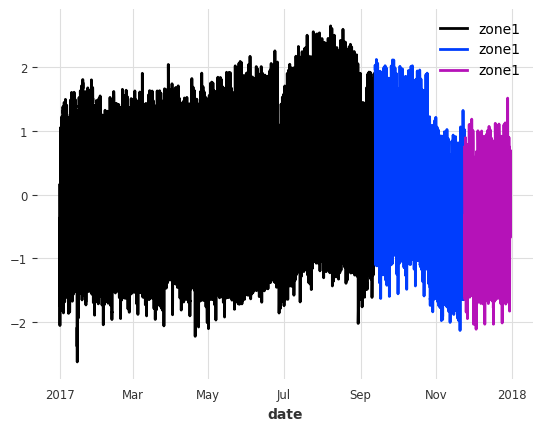

In [ ]:
trainY, testY = Y.split_after(0.7)
testY, valY = testY.split_after(0.66)

print(len(trainY))
print(len(testY))
print(len(valY))

trainY.plot()
testY.plot()
valY.plot()

In [ ]:
futuros=23

In [ ]:
import pytorch_lightning as pl

# Fijar la semilla para la reproducibilidad
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [ ]:
import logging
log = logging.getLogger("pytorch_lightning")
log.propagate = False
log.setLevel(logging.ERROR)

In [ ]:
from pytorch_lightning.callbacks import Callback

class LossRecorder(Callback):
    def __init__(self):
        self.train_loss_history = []
        self.val_loss_history = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss_history.append(trainer.callback_metrics["train_loss"].item())
        self.val_loss_history.append(trainer.callback_metrics["val_loss"].item())

In [ ]:
params = {'batch_size': 64, 'dropout': 0.4, 'hidden_continuous_size': 16, 'hidden_size': 256, 'learning_rate': 0.003433258483724734, 'lstm_layers': 3.0, 'num_attention_heads': 2}


early_stopper = pl.callbacks.EarlyStopping(
monitor="val_loss",
patience=15,
min_delta=0,
mode='min',
verbose = True
)

loss_recorder = LossRecorder()

my_model = TFTModel(
    input_chunk_length=pasados,
    output_chunk_length=1,
    hidden_size=int(params["hidden_size"]),
    dropout=float(params["dropout"]),
    batch_size=int(params["batch_size"]),
    n_epochs=128,
    optimizer_kwargs={"lr": float(params["learning_rate"])},
    random_state=42,
    add_relative_index= True,
    loss_fn=torch.nn.MSELoss(),
    likelihood=None,
    output_chunk_shift = futuros,
    save_checkpoints = True,
    use_static_covariates = False,
    lstm_layers = int(params["lstm_layers"]),
    hidden_continuous_size = int(params["hidden_continuous_size"]),
    num_attention_heads = int(params["num_attention_heads"]),
    pl_trainer_kwargs= {"callbacks": [early_stopper, loss_recorder],
                        "accelerator": "gpu", 
                        "devices": "auto"}
)
my_model.fit(
    series=trainY,
    val_series=testY,
    past_covariates=trainX,
    val_past_covariates=testX,
    verbose=True
)
my_model = TFTModel.load_from_checkpoint(model_name=my_model.model_name, best=True)



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/darts/models/forecasting/torch_forecasting_model.py:1842: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: TorchForecastingModel 

In [ ]:
# Crear todas las ventanas de 12 pasos
windowed_target_series = [valY[i:i + 12] for i in range(0, len(valY) - 12)]
windowed_covariates_series = [valX[i:i + 12] for i in range(0, len(valX) - 12)]
batch_size = 32
all_predictions = []
# Dividimos las ventanas en lotes (batches)
for i in range(0, len(windowed_target_series), batch_size):
    batch_target_windows = windowed_target_series[i:i + batch_size]
    batch_covariates_windows = windowed_covariates_series[i:i + batch_size]

    # Hacer la predicción para este lote de ventanas
    predictions = my_model.predict(
        n=1,  # Predecir solo un valor futuro para cada ventana
        series=batch_target_windows,  # Ventanas de la serie target
        past_covariates=batch_covariates_windows,  # Ventanas de las covariantes
        batch_size=batch_size,  # Tamaño del batch
        verbose=False
    )
    for pred in predictions:
        all_predictions.extend(pred.values())


preds = np.array(all_predictions)


trues = np.array(valY[pasados+futuros:].values())
if len(trues) > len(preds):
  trues = trues[:len(preds)]
else:
    preds = preds[:len(trues)]


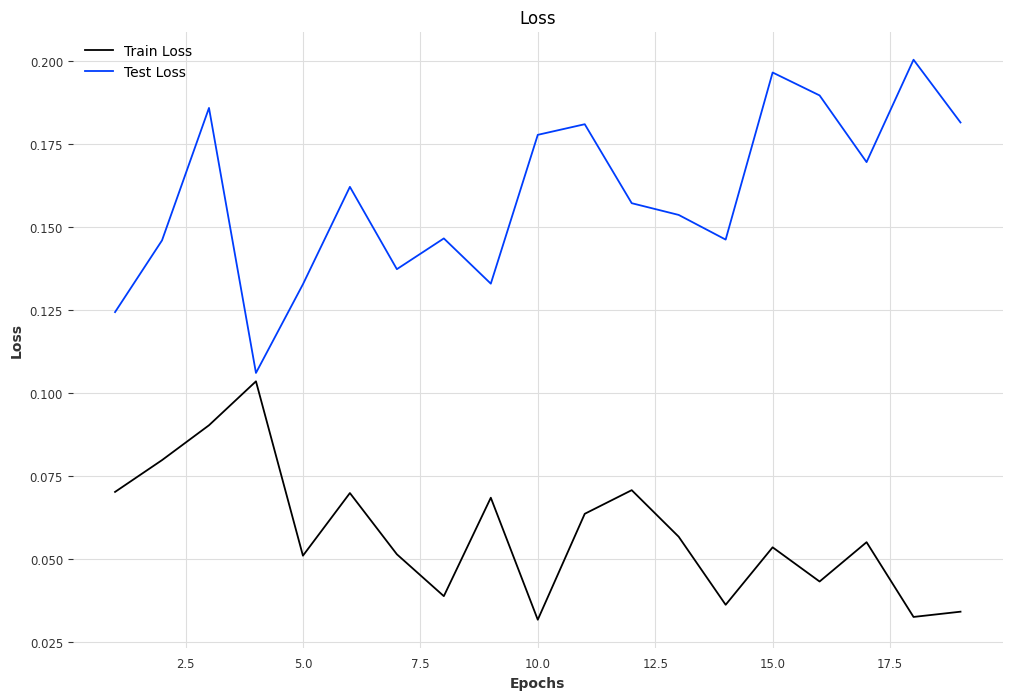

In [ ]:
ejeXTFT = range(1, len(loss_recorder.train_loss_history) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXTFT, loss_recorder.train_loss_history, label='Train Loss')
plt.plot(ejeXTFT, loss_recorder.val_loss_history, label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [ ]:
# Calcular MSE
mse = mean_squared_error(trues, preds)

# Calcular RMSE
rmse_value = rmse(trues, preds)

# Calcular MAE
mae = mean_absolute_error(trues, preds)

smape_value = smape(trues, preds)

ia_value = ia(trues, preds)


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.13460335491367914
RMSE: 0.3668832987663504
MAE: 0.3142667451327027
SMAPE: 0.7541129726686907
IA: 0.7916011915364025


In [ ]:
from datetime import timedelta

# Fecha y hora de término del conjunto de datos de prueba
end_date = datosNormalizados.index[-1]
n_observations = len(valY)

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(minutes=10 * (n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='10T')

val_date = val_date[pasados+futuros:]

<ipython-input-32-948f91a9b18e>:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='10T')


In [ ]:
df

,Originales,Predichos
0,-1.447386,-1.321104
1,-1.495731,-1.320792
2,-1.527962,-1.319684
3,-1.505909,-1.318097
4,-1.527962,-1.315526
...,...,...
5307,-0.247596,-0.038460
5308,-0.348215,-0.160756
5309,-0.463926,-0.288583
5310,-0.551129,-0.439929


In [ ]:
print(len(valY))

5347


In [ ]:
datosNormalizados.tail(2)

,temp,zone1,zone2,zone3,hour
date,,,,,
2017-12-30 23:40:00,-2.019162,-0.551129,0.838138,-1.007350,1.663044
2017-12-30 23:50:00,-2.047958,-0.634978,0.712438,-1.033201,1.663044


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': trues.flatten(), 'Predichos': preds.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]

fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')

fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))

fig.show()

In [ ]:
df.to_csv("/content/drive/MyDrive/transformers/errores/24paso/tftConsumption.csv", index=True)

In [ ]:
# Crear todas las ventanas de 12 pasos
windowed_target_series = [Y[i:i + 12] for i in range(0, len(Y) - 12)]
windowed_covariates_series = [X[i:i + 12] for i in range(0, len(X) - 12)]
batch_size = 32
final_predictions = []
# Dividimos las ventanas en lotes (batches)
for i in range(0, len(windowed_target_series), batch_size):
    batch_target_windows = windowed_target_series[i:i + batch_size]
    batch_covariates_windows = windowed_covariates_series[i:i + batch_size]

    # Hacer la predicción para este lote de ventanas
    predictions = my_model.predict(
        n=1,  # Predecir solo un valor futuro para cada ventana
        series=batch_target_windows,  # Ventanas de la serie target
        past_covariates=batch_covariates_windows,  # Ventanas de las covariantes
        batch_size=batch_size,  # Tamaño del batch
        verbose=False
    )
    for pred in predictions:
        final_predictions.extend(pred.values())

final_predictions = np.array(final_predictions)




In [ ]:
final_predictions2 = final_predictions[:-futuros]
final_predictions2[-1]

array([-0.50344041])

In [ ]:
print(len(final_predictions2))

52381


In [ ]:
trues2 = np.array(Y[pasados+futuros:].values())

In [ ]:
nans_start = np.full(pasados+futuros, np.nan)
nan_end = np.array([np.nan])
error = trues2 - final_predictions2

e = np.concatenate((nans_start, np.squeeze(error)))

In [ ]:
df3 = datosNormalizados.reset_index()

In [ ]:
df3["error"] = e

In [ ]:
df3.tail(15)

,date,temp,zone1,zone2,zone3,hour,error
52401,2017-12-30 21:30:00,-1.826327,0.322576,2.053724,-0.531340,1.374009,-0.564647
52402,2017-12-30 21:40:00,-1.874859,0.225311,1.954181,-0.547385,1.374009,-0.549767
52403,2017-12-30 21:50:00,-1.795589,0.208542,1.824121,-0.594629,1.374009,-0.460416
52404,2017-12-30 22:00:00,-1.803678,0.270590,1.776166,-0.614240,1.518526,-0.303819
52405,2017-12-30 22:10:00,-1.876477,0.245435,1.714406,-0.648114,1.518526,-0.230066
52406,2017-12-30 22:20:00,-1.874859,0.188418,1.624309,-0.671290,1.518526,-0.193273
52407,2017-12-30 22:30:00,-1.902361,0.112954,1.536391,-0.692684,1.518526,-0.190701
52408,2017-12-30 22:40:00,-1.916921,0.059291,1.454287,-0.715860,1.518526,-0.158758
52409,2017-12-30 22:50:00,-1.925009,-0.019527,1.404878,-0.750625,1.518526,-0.140796
52410,2017-12-30 23:00:00,-1.968689,-0.110084,1.347478,-0.779150,1.663044,-0.142669


In [ ]:
df3.head(40)

,date,temp,zone1,zone2,zone3,hour,error
0,2017-01-01 00:00:00,-2.051356,0.151445,-0.851669,0.033500,-1.660858,NaN
1,2017-01-01 00:10:00,-2.074813,-0.433079,-0.211097,0.016502,-1.660858,NaN
2,2017-01-01 00:20:00,-2.091152,-0.527709,-0.283791,-0.055068,-1.660858,NaN
3,2017-01-01 00:30:00,-2.122213,-0.651648,-0.411186,-0.174054,-1.660858,NaN
4,2017-01-01 00:40:00,-2.154568,-0.774750,-0.507632,-0.244729,-1.660858,NaN
5,2017-01-01 00:50:00,-2.165569,-0.872729,-0.597600,-0.293039,-1.660858,NaN
6,2017-01-01 01:00:00,-2.199865,-0.958984,-0.681090,-0.321667,-1.516340,NaN
7,2017-01-01 01:10:00,-2.223323,-1.035189,-0.746587,-0.396816,-1.516340,NaN
8,2017-01-01 01:20:00,-2.193880,-1.127306,-0.832236,-0.463913,-1.516340,NaN
9,2017-01-01 01:30:00,-2.224132,-1.195976,-0.889096,-0.499698,-1.516340,NaN


In [ ]:
df3.to_csv("/content/drive/MyDrive/transformers/datosNarmax/24_consumption_tft", index=True)

In [ ]:
model_save_path = '/content/drive/My Drive/transformers/modelosEntrenados/NARX/24_consumption_tft.pt'
my_model.save(model_save_path)